# Experiment 4: Basic Obstacle Avoidance using Spatial Coupling

This notebook introduces obstacle avoidance into the 3D discrete DMP
framework using the spatial coupling method.

# Spatial coupling function
this severses as the heart of teh coupling term that will be used in the our OA DMP

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Performance_measuring import test_dmp_performance

def spatial_coupling_OA(
        y, 
        ydot,
        obstacles, 
        gamma=1000.0,
        beta=6.0,
        eps=1e-9
        ):

    #turn into 1D vectors
    y = np.asarray(y).reshape(-1,)
    ydot = np.asarray(ydot).reshape(-1,)

    
    d_dim = y.shape[0] # dimension of space
    Ct_total = np.zeros(d_dim) # coupling terms for each obstacle

    vnorm = np.linalg.norm(ydot) # normalizes velocity
    if vnorm < eps: # steering angles becomes meaningless when vnorm = 0 since it's stationary
        return Ct_total
 
    for o in obstacles:
        o = np.asarray(o).reshape(-1,) # 1D vector
        dvec = o - y # getting difference
        dnorm = np.linalg.norm(dvec) # getting normailized difference
        if dnorm < eps: # angle would be meaningless if we're exactly on the obstacle, so just skip this one
            continue

        # steering angle psi = arccos( (d^T ydot) / (||d|| ||ydot|| + eps) )
        cosang = np.dot(dvec, ydot) / (dnorm * vnorm + eps)
        cosang = np.clip(cosang, -1.0, 1.0) # ensure within range 
        psi = np.arccos(cosang) # steering angle between 0 and pi

        # Compute R ydot
        if d_dim == 2:
            # choose side based on sign of (d x v)_z
            cross_z = dvec[0]*ydot[1] - dvec[1]*ydot[0]
            sign = 1.0 if cross_z >= 0 else -1.0
            Rydot = sign * np.array([-ydot[1], ydot[0]])

        elif d_dim == 3:
            r = np.cross(dvec, ydot)
            rnorm = np.linalg.norm(r)
            rhat = r / (rnorm+eps)

            # simplified Rodrigues for theta = pi/2:
            Rydot = np.cross(rhat, ydot) + rhat * np.dot(rhat, ydot)
        else:
            raise ValueError("Only 2D or 3D supported.")

        Ct_total += gamma * Rydot * psi * np.exp(-beta * psi)

    return Ct_total


ModuleNotFoundError: No module named 'Performance_measuring'

# DMP & OA
Reuses same DMP function from experiment 3 with the integrating a coupling term.

In [ ]:
def dmp_discrete_3d_OA(
    pos, 
    dt,
    kp=150.0, 
    kv=25.0, 
    alpha=5.0, 
    basis_num=40,
    speed=1.0,
    start_shift=None,
    goal_shift=None,
    spatial_scale=None,
    init_vel_scale=1.0,
    init_vel_offset=None,
    obstacles=None,
    oa_gamma=1000.0,
    oa_beta=6.0
):   
    pos = np.asarray(pos) # checks demonstration is in correct form
    assert pos.ndim == 2 and pos.shape[0] == 3, "pos must be shape (3, T)"
    assert speed > 0, "speed must be > 0"

    if obstacles is None:
        obstacles = []

    T = pos.shape[1] # number of intervals

    tau_demo = dt * T # duration of the demonstration (for learning)
    tau_new  = tau_demo / speed # new duration of demonstration

    vel = np.gradient(pos, axis=-1)/dt # velocity using derivative
    acc = np.gradient(vel, axis=-1)/dt # acceleration

    # Goal / start  shift and speed setup
    goal = pos[:, -1]
    demo_start = pos[:, 0]
    demo_goal  = pos[:, -1]

    if start_shift is None:
        start_shift = np.zeros(3)
    if goal_shift is None:
        goal_shift = np.zeros(3)

    start_shift = np.asarray(start_shift).reshape(3,)
    goal_shift  = np.asarray(goal_shift).reshape(3,)

    newStart = demo_start+start_shift
    newGoal  = demo_goal+goal_shift

    if init_vel_offset is None:
        init_vel_offset = np.zeros(3)
    init_vel_offset = np.asarray(init_vel_offset).reshape(3,)


    demo_displacement = demo_goal-demo_start
    new_displacement  = newGoal-newStart

    if spatial_scale is None:
        spatial_scale = np.ones(3)
        for d in range(3):
            if abs(demo_displacement[d])>1e-8:
                spatial_scale[d] = new_displacement[d] / demo_displacement[d]
    else:
        spatial_scale = np.asarray(spatial_scale).reshape(3,)

    # basis setup
    u = np.zeros(basis_num)
    c = np.zeros(basis_num)
    h = np.zeros(basis_num)

    # control center loactions of gaussians
    for i in range(basis_num):
        u[i] = (1.0/basis_num)*i
        c[i] = np.exp(-alpha * u[i])

    # control spread of gaussians
    for i in range(basis_num - 1):
        h[i] = 0.5 / ((0.65 * (c[i+1] - c[i]))**2)
    h[basis_num - 1] = h[basis_num - 2]

    #  Learning
    Phi = np.zeros(basis_num)
    Phi_total = np.zeros((T, basis_num))
    force = np.zeros((T, 3))

    s = 1.0
    for i in range(T):
        s = -alpha*s*dt/tau_demo+s

        addsum = 0.0
        for b in range(basis_num):
            Phi[b] = np.exp(-h[b] * (s - c[b])**2)
            addsum += Phi[b]
        Phi = Phi / addsum * s
        Phi_total[i, :] = Phi

        # target forcing term
        force[i, :] = (tau_demo*tau_demo)*acc[:, i] - kp*(goal - pos[:, i]) + tau_demo*kv*vel[:, i]

    trainPattern = np.matmul(np.linalg.pinv(Phi_total), force)  # (basis_num, 3)

    # setup for reconstruction
    T_new = int(np.round(tau_new/dt)) # note the use tau_new so that the reconstruction happens at the wanted speed
    T_new = max(T_new, 2)

    DMP_pos = np.zeros((3, T_new))
    DMP_vel = np.zeros((3, T_new))
    DMP_acc = np.zeros((3, T_new))

    DMP_pos[:, 0] = newStart 
    DMP_vel[:, 0] = init_vel_scale * vel[:, 0] + init_vel_offset

    s = 1.0
    for i in range(T_new - 1):
        s = -alpha*s*dt/tau_new+s
        addsum = 0.0
        
        for b in range(basis_num):
            Phi[b] = np.exp(-h[b] * (s - c[b])**2)
            addsum = addsum + Phi[b]

        newForce = np.matmul(Phi / addsum, trainPattern) * s * spatial_scale

        # obstacle avoidance coupling term
        Ct = spatial_coupling_OA(
            DMP_pos[:, i],
            DMP_vel[:, i],
            obstacles,
            gamma=oa_gamma,
            beta=oa_beta
        )

        # transformation system
        DMP_acc[:, i] = (kp*(newGoal - DMP_pos[:, i]) - tau_new*kv*DMP_vel[:, i] + newForce + Ct) / (tau_new**2)
        DMP_pos[:, i+1] = DMP_pos[:, i] + DMP_vel[:, i] * dt
        DMP_vel[:, i+1] = DMP_vel[:, i] + DMP_acc[:, i] * dt

    return DMP_pos, DMP_vel, DMP_acc, trainPattern, tau_new, newStart, newGoal

## Helpers — Demo Generator and Multi-View Plotter

A swirl demonstration generator and a 4-view 3D plotting function used
across all the obstacle-avoidance experiments.

In [ ]:
def gen_3d_discrete_demo(dt=0.005, tau=2.0, Axy=1.0, z_amp=0.6):
    T = int(np.round(tau / dt))
    t = np.linspace(0, tau, T)

    u = t / tau

    x = Axy * np.cos(1.5 * np.pi * u)
    y = Axy * np.sin(1.5 * np.pi * u)
    z = z_amp * np.sin(np.pi * u)

    pos = np.vstack([x, y, z])
    return pos, t


def plot_dmp_views_points(pos, DMP_pos, objects, newGoal=None,views=((20, 45), (20, 135), (60, 45), (10, -60))):
    objs = np.asarray(objects, dtype=float).reshape(-1, 3)

    # combine all points to compute a shared axis range
    P = np.column_stack([pos[0], pos[1], pos[2]])
    Q = np.column_stack([DMP_pos[0], DMP_pos[1], DMP_pos[2]])
    pts = np.vstack([P, Q, objs])

    if newGoal is not None:
        pts = np.vstack([pts, np.asarray(newGoal, dtype=float).reshape(1, 3)])

    mins = pts.min(axis=0)
    maxs = pts.max(axis=0)
    max_range = float(np.max(maxs - mins))
    min_val = float(np.min(mins))

    fig = plt.figure(figsize=(10, 10))
    for i, (elev, azim) in enumerate(views[:4], start=1):
        ax = fig.add_subplot(2, 2, i, projection="3d")

        ax.plot(pos[0], pos[1], pos[2], label="demo")
        ax.plot(DMP_pos[0], DMP_pos[1], DMP_pos[2], label="DMP")
        ax.scatter(objs[:, 0], objs[:, 1], objs[:, 2], marker='o', s=80, label="obstacle")

        if newGoal is not None:
            g = np.asarray(newGoal, dtype=float).reshape(3,)
            ax.scatter(g[0], g[1], g[2], marker='x', s=60, label="goal")
        else:
            ax.scatter(pos[0, -1],pos[1, -1], pos[2, -1], marker='x', s=60, label="goal")

        ax.set_xlim(min_val, min_val + max_range)
        ax.set_ylim(min_val, min_val + max_range)
        ax.set_zlim(min_val, min_val + max_range)

        ax.set_xlabel("x"); 
        ax.set_ylabel("y"); 
        ax.set_zlabel("z")

        ax.view_init(elev=elev, azim=azim) # set the view angle for better visualization
        ax.legend()

    plt.tight_layout()
    plt.show()

## Example 1 — Curved Path

A 3D swirl demonstration with a static obstacle placed directly on the
midpoint of the path

min dist (demo -> obstacle): 0.0000
min dist (DMP  -> obstacle): 0.1395


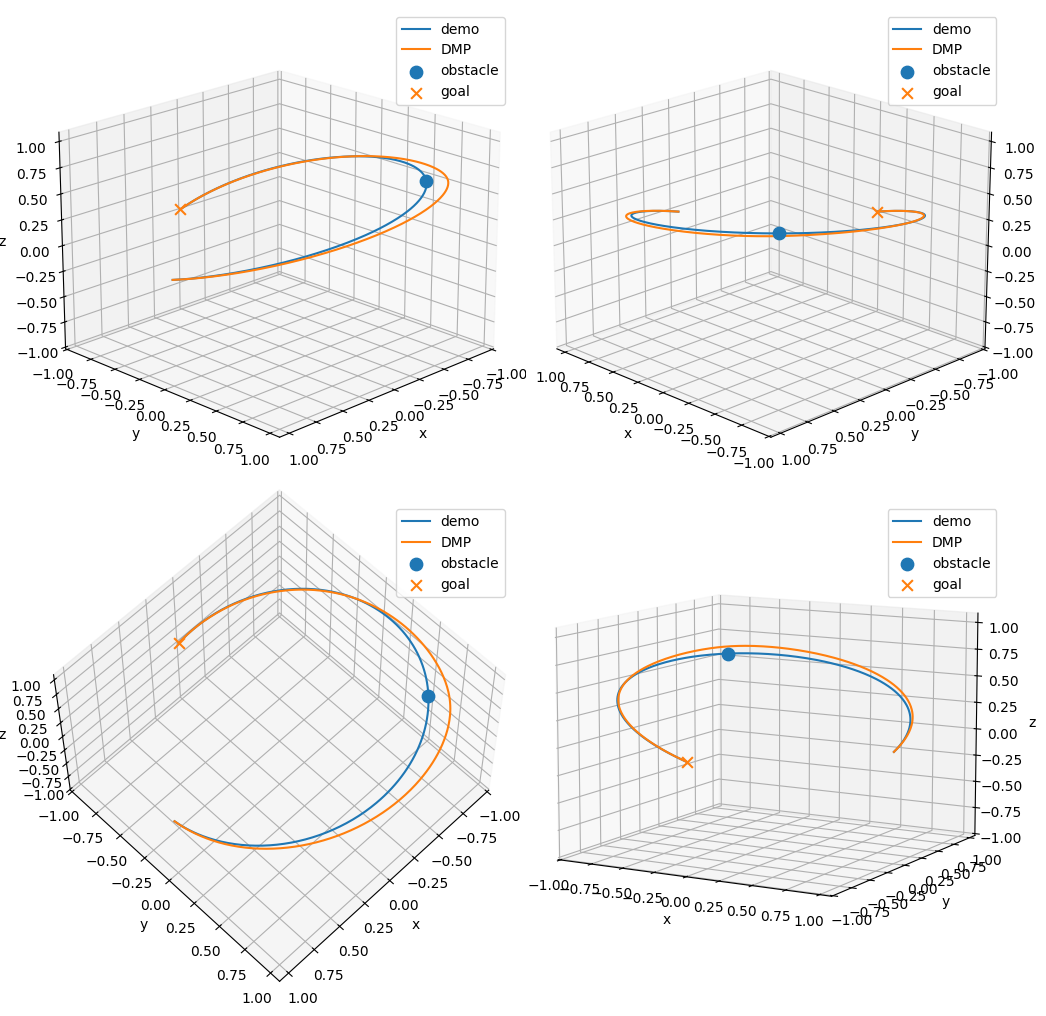

In [ ]:

dt = 0.005
pos, t_demo = gen_3d_discrete_demo(dt=dt, tau=2.0, Axy=1.0, z_amp=0.6)

mid = pos.shape[1] // 2
obstacle = pos[:, mid] + np.array([0.00, 0.00, 0.00])
obstacles = [obstacle]

DMP_pos, DMP_vel, DMP_acc, W, tau_new, newStart, newGoal = dmp_discrete_3d_OA(
    pos, dt,
    speed=1.0,
    start_shift=[0.0, 0.0, 0.0],
    goal_shift=[0.0, 0.0, 0.0],
    obstacles=obstacles,
    oa_gamma=1000.0,
    oa_beta=6.0
)

# report minimum distance to obstacle for both trajectories
d_demo = np.min(np.linalg.norm(pos.T - obstacle[None, :], axis=1))
d_dmp  = np.min(np.linalg.norm(DMP_pos.T - obstacle[None, :], axis=1))
print(f"min dist (demo -> obstacle): {d_demo:.4f}")
print(f"min dist (DMP  -> obstacle): {d_dmp:.4f}")

plot_dmp_views_points(pos, DMP_pos, objects=[obstacle], newGoal=newGoal)



min dist (demo -> obstacle): 0.0000
min dist (DMP  -> obstacle): 0.0000


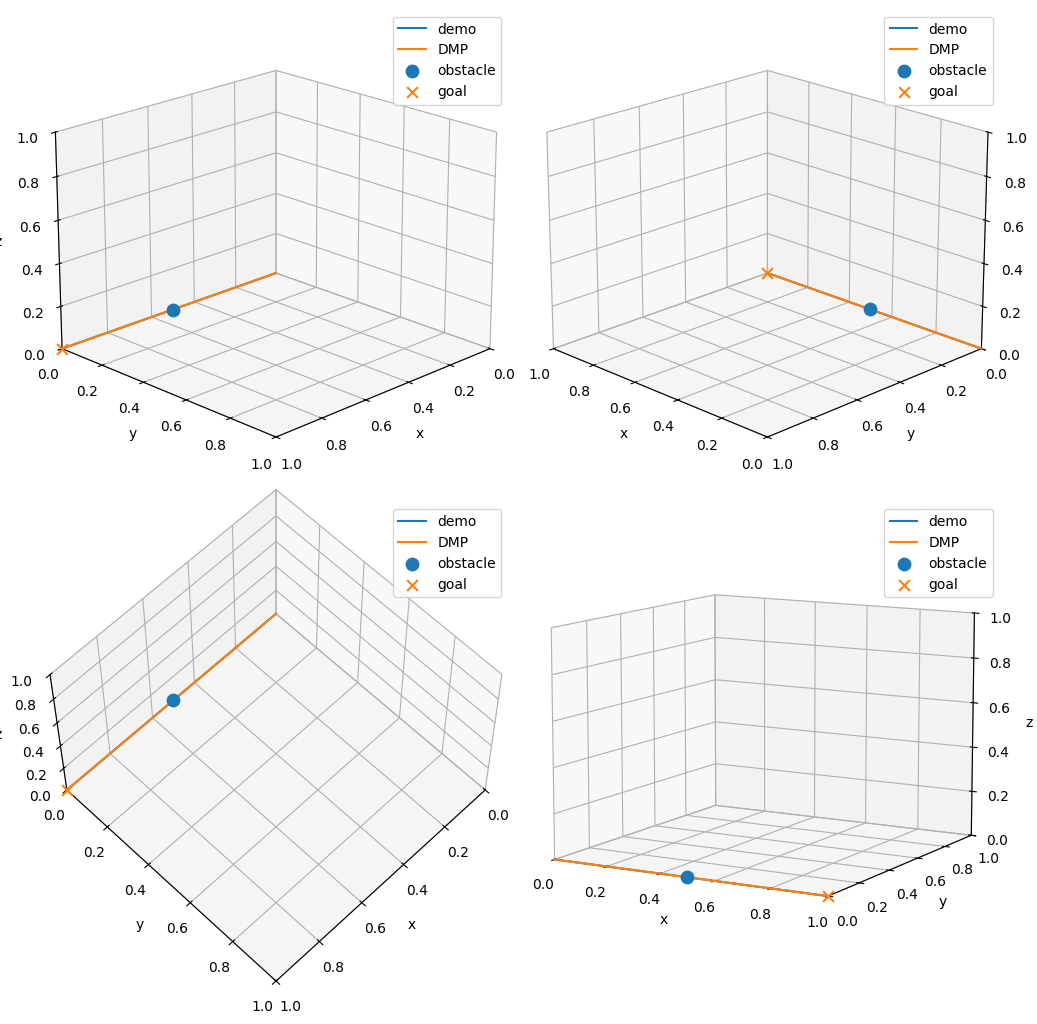

In [ ]:
dt = 0.005

# straight-line demo from start to goal
T = int(np.round(2.0 / dt))
t_demo = np.linspace(0, 2.0, T)

start = np.array([0.0, 0.0, 0.0])
goal  = np.array([1.0, 0.0, 0.0])

u = t_demo / 2.0
pos = np.vstack([
    start[0] + (goal[0] - start[0]) * u,
    start[1] + (goal[1] - start[1]) * u,
    start[2] + (goal[2] - start[2]) * u,
])

# obstacle placed exactly on the midpoint 
mid = pos.shape[1] // 2
obstacle = pos[:, mid] + np.array([0.00, 0.00, 0.00])
obstacles = [obstacle]

DMP_pos, DMP_vel, DMP_acc, W, tau_new, newStart, newGoal = dmp_discrete_3d_OA(
    pos, dt,
    speed=1.0,
    start_shift=[0.0, 0.0, 0.0],
    goal_shift=[0.0, 0.0, 0.0],
    obstacles=obstacles,
    oa_gamma=1000.0,
    oa_beta=6.0
)

d_demo = np.min(np.linalg.norm(pos.T - obstacle[None, :], axis=1))
d_dmp  = np.min(np.linalg.norm(DMP_pos.T - obstacle[None, :], axis=1))
print(f"min dist (demo -> obstacle): {d_demo:.4f}")
print(f"min dist (DMP  -> obstacle): {d_dmp:.4f}")

plot_dmp_views_points(pos, DMP_pos, objects=[obstacle], newGoal=newGoal)

In [ ]:
# example 1
pos1, _ = gen_3d_discrete_demo(dt=0.005, tau=2.0, Axy=1.0, z_amp=0.6)
obs1 = pos1[:, pos1.shape[1] // 2].copy()
DMP1, _, _, _, _, _, _ = dmp_discrete_3d_OA(
    pos1, 0.005, obstacles=[obs1], oa_gamma=400.0, oa_beta=5.0
)
_, m1 = test_dmp_performance(pos1, DMP1, obstacle_positions=[obs1])

# example 2
T2 = int(np.round(2.0 / 0.005))
u2 = np.linspace(0, 1, T2)
pos2 = np.vstack([u2, np.zeros_like(u2), np.zeros_like(u2)])
obs2 = pos2[:, T2 // 2].copy()
DMP2, _, _, _, _, _, _ = dmp_discrete_3d_OA(
    pos2, 0.005, obstacles=[obs2], oa_gamma=40000.0, oa_beta=1.0
)
_, m2 = test_dmp_performance(pos2, DMP2, obstacle_positions=[obs2])

print(" Example 1 — Curved Path")
for k, v in m1.items():
    print(f"  {k}: {v}")

print()
print(" Example 2 — Straight Line ")
for k, v in m2.items():
    print(f"  {k}: {v}")

=== Example 1 — Curved Path ===
  final_goal_error: 0.0008144067102254499
  RMS_tracking_error: 0.08720363094520672
  min_distance_each_obstacle: [0.12471325783988015]
  min_distance_overall: 0.12471325783988015
  original_path_length: 4.8955493723507875
  DMP_path_length: 5.108906173724083

=== Example 2 — Straight Line ===
  final_goal_error: 0.0004133362700351473
  RMS_tracking_error: 4.8657659706715076e-05
  min_distance_each_obstacle: [1.021184850014123e-07]
  min_distance_overall: 1.021184850014123e-07
  original_path_length: 1.0
  DMP_path_length: 1.0004133362700351
